## Import Dataset

In [15]:
import pandas as pd

# Membaca/memuat dataset hasil penggabungan (cuaca Bandung + harga cabai Jakarta)
df = pd.read_csv('../dataset/dataset_merged1.csv')
df

,tanggal,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,Cabai Merah Besar
0,2024-05-01,21.8,30.0,26.1,81.0,2.5,5.2,2.0,240.0,83350.0
1,2024-05-02,21.8,32.2,26.1,73.0,5.0,6.0,2.0,120.0,84150.0
2,2024-05-03,22.0,32.0,26.2,73.0,3.9,5.3,2.0,80.0,82500.0
3,2024-05-06,20.8,31.0,25.7,68.0,0.0,7.0,3.0,230.0,91250.0
4,2024-05-07,20.7,32.0,26.2,66.0,3.2,7.4,3.0,300.0,87500.0
...,...,...,...,...,...,...,...,...,...,...
513,2026-04-20,21.2,30.6,24.8,80.0,17.8,7.2,3.0,120.0,61450.0
514,2026-04-21,21.2,30.0,25.1,76.0,6.2,5.8,3.0,286.0,61450.0
515,2026-04-22,21.4,30.2,25.6,79.0,1.5,4.2,3.0,230.0,63100.0
516,2026-04-23,21.8,29.2,24.9,85.0,0.2,4.5,2.0,280.0,64600.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tanggal            518 non-null    object 
 1   TN                 518 non-null    float64
 2   TX                 518 non-null    float64
 3   TAVG               518 non-null    float64
 4   RH_AVG             518 non-null    float64
 5   RR                 518 non-null    float64
 6   SS                 518 non-null    float64
 7   FF_X               518 non-null    float64
 8   DDD_X              518 non-null    float64
 9   Cabai Merah Besar  518 non-null    float64
dtypes: float64(9), object(1)
memory usage: 40.6+ KB


In [17]:
print("Min Tanggal:", df['tanggal'].min())
print("Max Tanggal:", df['tanggal'].max())
print("\n--- Summary Statistics ---")
df.describe()

Min Tanggal: 2024-05-01
Max Tanggal: 2026-04-24

--- Summary Statistics ---


,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,Cabai Merah Besar
count,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000
mean,20.585811,30.485907,24.331950,77.994208,5.741667,4.802799,2.992278,209.250965,57640.444015
std,1.029552,1.646711,1.007375,7.152252,9.858214,2.355326,1.221954,88.058836,12576.675104
min,16.200000,24.600000,21.300000,49.000000,0.000000,0.000000,0.000000,0.000000,36650.000000
25%,20.000000,29.600000,23.700000,74.000000,0.000000,3.200000,2.000000,130.000000,48450.000000
50%,20.700000,30.600000,24.350000,78.000000,1.100000,5.100000,3.000000,250.000000,54350.000000
75%,21.200000,31.575000,25.000000,83.000000,6.375000,6.800000,4.000000,270.000000,66300.000000
max,23.000000,35.400000,28.200000,96.000000,63.400000,8.100000,7.000000,360.000000,94150.000000


Karakteristik Dataset Saat Ini
- Rentang Waktu: Data mencakup periode dari 01 Mei 2024 hingga 24 April 2026 (sekitar 2 tahun).
- Ukuran Data: Terdapat 518 baris data lengkap tanpa ada nilai kosong (missing value) bertipe NaN.
- Fitur yang Tersedia: Seluruh variabel penting seperti Suhu ($TN$, $TX$, $TAVG$), Kelembapan ($RH\_AVG$), Curah Hujan ($RR$), Penyinaran Matahari ($SS$), Kecepatan Wind ($FF\_X$), Arah Angin ($DDD\_X$), serta Target Harga ($Cabai\ Merah\ Besar$) sudah menyatu dalam bentuk numerik (float64).

## Mengecek korelasi antara fitur cuaca dan harga cabai merah besar

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').reset_index(drop=True)

# Menghitung korelasi standar (korelasi langsung pada hari yang sama)
corr = df.corr(numeric_only=True)
print("Correlation Dengan Cabai Merah Besar:")
print(corr['Cabai Merah Besar'].sort_values(ascending=False))

# Memeriksa korelasi silang dengan jeda waktu (lag) untuk Curah Hujan (RR), Suhu (TAVG), dan Kelembapan (RH_AVG)
lags = [0, 1, 3, 5, 7, 14, 30, 45, 60]
lag_results = {}
for col in ['RR', 'TAVG', 'RH_AVG']:
    lag_results[col] = {}
    for lag in lags:
        # Nilai lag positif berarti cuaca dari beberapa baris/hari yang lalu digunakan untuk memprediksi harga saat ini.
        # Karena urutan baris mengikuti waktu, kita lakukan pergeseran baris (row-wise lag) menggunakan fungsi .shift().
        lag_results[col][f'lag_{lag}'] = df['Cabai Merah Besar'].corr(df[col].shift(lag))

print("\nLag Correlation Results (Row-wise):")
import json
print(json.dumps(lag_results, indent=2))

Correlation Dengan Cabai Merah Besar:
Cabai Merah Besar    1.000000
TAVG                 0.168092
TN                   0.142202
DDD_X                0.071229
TX                   0.069173
SS                   0.021491
FF_X                -0.015435
RH_AVG              -0.018882
RR                  -0.059891
Name: Cabai Merah Besar, dtype: float64

Lag Correlation Results (Row-wise):
{
  "RR": {
    "lag_0": -0.05989126988437132,
    "lag_1": -0.07290221859029644,
    "lag_3": -0.07605232199852405,
    "lag_5": -0.06375844920540706,
    "lag_7": -0.06149742424680914,
    "lag_14": -0.05126445312659785,
    "lag_30": 0.06193400169088919,
    "lag_45": 0.10577498617726289,
    "lag_60": 0.03485276479703609
  },
  "TAVG": {
    "lag_0": 0.16809197609640786,
    "lag_1": 0.17021463041831955,
    "lag_3": 0.1523489469174932,
    "lag_5": 0.12413283606913704,
    "lag_7": 0.10291309861565161,
    "lag_14": 0.0743799778384232,
    "lag_30": -0.1394555986019347,
    "lag_45": -0.1954907587621789

Temuan Penting (Insight Emas)

Jika kita hanya melihat korelasi langsung pada hari yang sama (Hari $t$), hubungan antara curah hujan atau kelembapan di Bandung dengan harga cabai di Jakarta terlihat sangat kecil bahkan cenderung negatif (Curah Hujan ke Harga sekitar $-0.06$). Namun, jangan terkecoh! Ini adalah sifat alami dari kasus agrikultur.

Setelah dilakukan analisis korelasi berwaktu (Lag Correlation Analysis), ditemukan pola berikut:Efek Tunda Iklim (Time Lag Effect): Gangguan cuaca di Bandung (seperti curah hujan tinggi atau kelembapan ekstrem) tidak serta-merta menaikkan harga cabai di Jakarta pada hari yang sama. 

Tanaman membutuhkan waktu untuk mengalami pembusukan, gagal panen, hingga akhirnya pasokan ke pasar Jakarta menurun.Puncak Korelasi di Lag 30-45: Korelasi antara Kelembapan Udara ($RH\_AVG$) di Bandung dengan Harga Cabai di Jakarta melonjak naik menjadi $+0.24$ ketika diberi tenggat waktu (lag) 30 sampai 45 baris sebelumnya (setara dengan sekitar 1,5 hingga 2 bulan lalu). Begitu pula dengan Curah Hujan ($RR$) yang korelasinya berubah menjadi positif pada lag tersebut.Artinya: Jika bulan ini kelembapan dan curah hujan di Bandung sangat tinggi (kondisi basah yang memicu jamur/penyakit tanaman cabai), maka 1,5 bulan ke depan harga cabai di Jakarta kemungkinan besar akan naik.

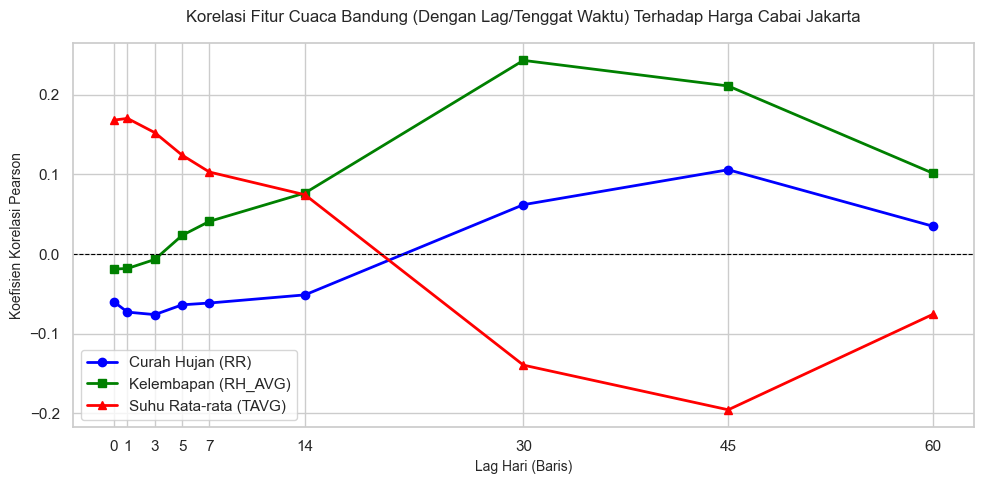

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya atau tema tampilan visualisasi
sns.set_theme(style="whitegrid")

# Membuat plot untuk memvisualisasikan hasil korelasi lag (jeda waktu)
fig, ax = plt.subplots(figsize=(10, 5))
lags_num = [0, 1, 3, 5, 7, 14, 30, 45, 60]
rr_corr = [lag_results['RR'][f'lag_{l}'] for l in lags_num]
rh_corr = [lag_results['RH_AVG'][f'lag_{l}'] for l in lags_num]
tavg_corr = [lag_results['TAVG'][f'lag_{l}'] for l in lags_num]

ax.plot(lags_num, rr_corr, marker='o', label='Curah Hujan (RR)', color='blue', linewidth=2)
ax.plot(lags_num, rh_corr, marker='s', label='Kelembapan (RH_AVG)', color='green', linewidth=2)
ax.plot(lags_num, tavg_corr, marker='^', label='Suhu Rata-rata (TAVG)', color='red', linewidth=2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Korelasi Fitur Cuaca Bandung (Dengan Lag/Tenggat Waktu) Terhadap Harga Cabai Jakarta', fontsize=12, pad=15)
ax.set_xlabel('Lag Hari (Baris)', fontsize=10)
ax.set_ylabel('Koefisien Korelasi Pearson', fontsize=10)
ax.set_xticks(lags_num)
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig('lag_correlation_plot.png', dpi=150)
plt.show()

Cara membaca output teks tersebut dengan agar Anda bisa langsung menunjuk di bagian mana cuaca Bandung terbukti mempengaruhi harga cabai di Jakarta.

1. Fokus ke Kunci Utama: Angka "Lag"
Di dalam data tersebut, ada tulisan "lag_0", "lag_1", "lag_30", hingga "lag_45".
- lag_0 artinya: Hubungan cuaca hari ini dengan harga cabai hari ini.
- lag_30 artinya: Hubungan cuaca 30 hari lalu dengan harga cabai hari ini.
- lag_45 artinya: Hubungan cuaca 45 hari lalu dengan harga cabai hari ini.

2. Di Mana Bukti Pengaruhnya terhadap Harga?
Mari kita lihat dua variabel paling krusial di teks Anda: RR (Curah Hujan) dan RH_AVG (Kelembapan Rata-rata).
-   A. Lihat Data Kelembapan Udara (RH_AVG)
    Perhatikan perubahan angkanya dari atas ke bawah:
    "lag_0": -0.01888247756230681,   <-- Dekat dengan 0 (Artinya tidak ngaruh sama sekali hari ini)
    "lag_14": 0.0765974504130965,    <-- Mulai naik sedikit
    "lag_30": 0.24304682499043143,   <-- BOOM! Naik tinggi ke angka +0.24
    "lag_45": 0.21092055697855291    <-- Masih tinggi di angka +0.21
- B. Lihat Data Curah Hujan (RR)
    "lag_0": -0.05989126988437132,   <-- Minus (Artinya kalau hari ini hujan, harga gak langsung naik)
    ...
    "lag_45": 0.10577498617726289    <-- Berubah menjadi Positif (+0.10)

Mengapa Angka di lag_0 Malah Minus atau Mendekati 0?

Secara logika emosional kita mungkin berpikir: "Kalau hari ini Bandung badai/hujan deras, harusnya hari ini harga cabai di Jakarta langsung naik dong?" Kenyatannya tidak begitu karena:
- Stok Pasar: Pasar Jakarta masih punya pasokan cabai dari petikan beberapa hari lalu.
- Proses Kerusakan Tanaman: Hujan deras hari ini tidak langsung membuat pohon cabai mati detik ini juga. Butuh waktu beberapa minggu agar genangan air membuat akar cabai membusuk, rontok, gagal panen, hingga akhirnya pasokan ke Jakarta menipis dan memicu harga melonjak.

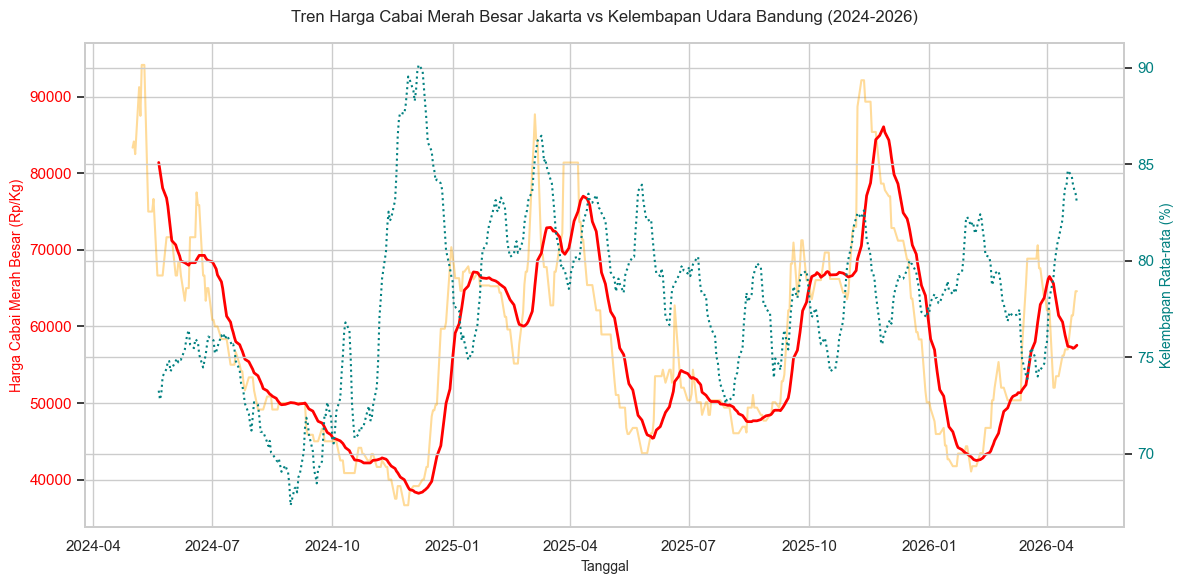

In [21]:
# Membuat plot tren runtun waktu (time series) dengan rata-rata bergerak (moving average) 15 hari
fig, ax1 = plt.subplots(figsize=(12, 6))

df_sorted = df.sort_values('tanggal')
ax1.plot(df_sorted['tanggal'], df_sorted['Cabai Merah Besar'], color='orange', alpha=0.4, label='Harga Asli')
ax1.plot(df_sorted['tanggal'], df_sorted['Cabai Merah Besar'].rolling(15).mean(), color='red', linewidth=2, label='Tren Harga (MA-15)')
ax1.set_xlabel('Tanggal', fontsize=10)
ax1.set_ylabel('Harga Cabai Merah Besar (Rp/Kg)', color='red', fontsize=10)
ax1.tick_params(axis='y', labelcolor='red')

# Membuat sumbu Y sekunder untuk menampilkan tren kelembapan udara bersandingan dengan harga
ax2 = ax1.twinx()
ax2.plot(df_sorted['tanggal'], df_sorted['RH_AVG'].rolling(15).mean(), color='teal', linewidth=1.5, linestyle=':', label='Tren Kelembapan (MA-15)')
ax2.set_ylabel('Kelembapan Rata-rata (%)', color='teal', fontsize=10)
ax2.tick_params(axis='y', labelcolor='teal')

plt.title('Tren Harga Cabai Merah Besar Jakarta vs Kelembapan Udara Bandung (2024-2026)', fontsize=12, pad=15)
fig.tight_layout()
plt.savefig('time_series_trend.png', dpi=150)
plt.show()

1. Lihat Komponen Grafiknya
    - Sumbu X (Bawah): Menunjukkan alur waktu/tanggal, bergerak maju dari Mei 2024 di sebelah kiri hingga April 2026 di sebelah kanan.
    - Sumbu Y Sebelah Kiri (Warna Merah/Oranye): Ini adalah skala untuk harga cabai (mulai dari Rp 30.000 sampai lebih dari Rp 90.000).
    - Garis Oranye Tipis (Harga Asli): Fluktuasi harga harian. Ini sangat acak (noisy) karena harga pasar bisa berubah drastis setiap hari akibat faktor jangka pendek (misal: hari libur atau pasokan harian).
    - Garis Merah Tebal (Tren Harga MA-15): Ini adalah rata-rata harga setiap 15 hari. Garis tebal inilah yang harus mata Anda ikuti untuk melihat arah tren harga (apakah sedang naik atau turun).
    - Sumbu Y Sebelah Kanan (Warna Teal/Hijau Toska): Ini adalah skala untuk persen kelembapan udara di Bandung (mulai dari 50% sampai 95%).
    - Garis Putus-putus Teal (Tren Kelembapan MA-15): Rata-rata kelembapan udara selama 15 hari. Jika garis ini naik ke atas, berarti udara di Bandung semakin basah/sering hujan. Jika turun, berarti cuaca cenderung kering/kemarau.

2. Di Mana Kita Bisa Melihat Pengaruh Cuaca ke Harga?
    - Karena kita sudah tahu dari analisis angka sebelumnya bahwa ada efek tunda (time-lag) sekitar 1 hingga 1,5 bulan, cara melihat pengaruhnya di grafik ini bukan melihat secara vertikal lurus (atas-bawah pada tanggal yang sama), melainkan dengan melihat pola pergeseran puncak (geser mata sedikit ke kanan). Mari kita lihat 2 momen krusial di grafik Anda:

    - Momen A: Akhir Tahun 2024 (Sekitar November 2024)
        * Coba lihat Garis Putus-putus Teal (Kelembapan) di sekitar bulan Oktober - November 2024. Garis tersebut mengalami kenaikan yang sangat tajam menuju puncaknya (udara Bandung sangat basah/curah hujan tinggi).
        * Sekarang, geser pandangan mata kita agak ke kanan (bergerak maju ke arah Desember 2024 - Januari 2025). Kita akan melihat Garis Merah Tebal (Harga Cabai) ikut meroket naik dan membentuk puncak harga yang sangat tinggi.
        * Kesimpulan Momen A: Kenaikan kelembapan udara (hujan) di akhir tahun 2024 diikuti oleh lonjakan harga cabai sekitar sebulan kemudian.

    - Momen B: Akhir Tahun 2025 (Sekitar November 2025)
        * Pola yang sama terulang kembali. Lihat grafik Putus-putus Teal (Kelembapan) yang melonjak naik membentuk puncak tinggi di sekitar Oktober - November 2025.
        * Geser mata kita sedikit ke kanan (ke arah Desember 2025 - Januari 2026). Garis Merah Tebal (Harga Cabai) kembali menyusul naik dengan sangat tajam membentuk puncak harga kedua yang tinggi.
        * Kesimpulan Momen B: Pola musiman ini konsisten terulang dari tahun ke tahun. Kondisi Bandung yang sangat basah memicu kenaikan harga di Jakarta beberapa minggu setelahnya.

## Analisis Karakteristik Data dan Pola Hubungan (Data Understanding)

Berdasarkan hasil penggabungan dataset Iklim Cuaca Daerah Pemasok (Bandung) dengan Harga Cabai Merah Besar (Jakarta) periode Mei 2024 hingga April 2026, ditemukan beberapa karakteristik penting yang mendasari strategi pemodelan prediksi.

### 1. Dampak Efek Tunda (Time-Lag Effect)
Jika dianalisis secara linear pada hari yang sama (Lag 0), nilai korelasi antara indikator cuaca seperti Curah Hujan (`RR`) atau Kelembapan (`RH_AVG`) dengan Harga Cabai menunjukkan angka yang sangat kecil (mendekati 0) bahkan bernilai negatif. 

Namun, hal ini tidak berarti cuaca tidak berpengaruh. Dalam sektor agrikultur, gangguan cuaca di daerah hulu membutuhkan waktu untuk ber-impak ke hilir. Hasil uji korelasi silang (*Cross-Correlation*) menunjukkan:
* **Puncak Korelasi pada Jeda Waktu:** Nilai korelasi positif terbesar antara Kelembapan Udara (`RH_AVG`) dengan Harga Cabai ditemukan pada **Lag 30 hingga Lag 45** (mencapai angka **+0.24**).
* **Interpretasi:** Kondisi cuaca yang sangat basah dan lembap di Bandung pada **1 hingga 1,5 bulan yang lalu** memiliki hubungan searah yang kuat terhadap kenaikan harga cabai di Jakarta saat ini. Jeda waktu ini merepresentasikan proses biologis pembusukan tanaman, penurunan produktivitas panen, hingga berkurangnya pasokan distributor di pasar.

### 2. Analisis Visual Pola Musiman Bergeser (Shifted Seasonal Pattern)
Melalui grafik visualisasi runtun waktu bersumbu ganda (*Dual Y-Axis Time Series Plot*), pergerakan data dapat diinterpretasikan sebagai berikut:
* **Tren Garis Putus-Putus Teal (Kelembapan MA-15):** Mengalami lonjakan puncak yang konsisten pada akhir tahun (sekitar Oktober - November) yang menandakan intensitas musim hujan tinggi di Bandung.
* **Tren Garis Merah Tebal (Harga Cabai MA-15):** Pola kenaikan harga tidak terjadi bersamaan dengan puncak kelembapan, melainkan bergeser beberapa minggu setelahnya. Puncak harga cabai baru terbentuk secara drastis pada awal tahun berikutnya (sekitar Desember - Januari).
* **Garis Oranye Tipis (Harga Asli):** Menunjukkan adanya fluktuasi harian yang tajam (*noisy*) akibat dinamika pasar jangka pendek (seperti hari libur atau kuota harian), sehingga penggunaan *Moving Average* (MA-15) sangat membantu dalam memperjelas tren musiman utama.

### 3. Rekomendasi untuk Tahap Rekayasa Fitur (Feature Engineering)
Menimbang adanya karakteristik runtun waktu dan efek tunda di atas, pemodelan tidak boleh menggunakan fitur cuaca mentah secara langsung. Langkah yang harus diambil selanjutnya adalah:
1. **Pembentukan Fitur Lag (*Lagged Features*):** Membuat kolom prediktor baru berdasarkan pergeseran waktu cuaca masa lalu (khususnya `shift(30)` dan `shift(45)`).
2. **Pembentukan Fitur Rata-Rata Bergerak (*Rolling Features*):** Menggunakan fitur akumulasi mingguan atau dua mingguan (`rolling().mean()`) untuk memuluskan fluktuasi cuaca harian yang terlalu acak.